# Seaborn

---
## Introducción

Seaborn es otro paquete de visualización de datos de Python.

Al igual que Matplolib, Seaborn es una librería de dibujo de trazos 2D, lo que implica que dibujará gráficos de líneas.

A pesar de que aquí veremos los aspectos básicos de la misma, os dejo el enlace a su documentación oficial en [este enlace](https://seaborn.pydata.org/api.html). También os dejo una serie de Notebooks donde presentan varios [ejemplos de uso](https://www.kaggle.com/getting-started/125556).

Al igual que pasaba anteriormente con el resto de librerías, Seaborn no viene instalado por defecto en Visual Studio Code por lo que tendremos que hacerlo nosotros:

In [1]:
# Recuerda que pip es el gestor de paquetes por defecto de Python
#pip install seaborn

Hay que tener en cuenta que Seaborn es una extensión de Matplotlib.Pyplot por lo que necesitará importar este módulo para poder funcionar. Además, como Mayplotlib necesita de NumPy aquí también será necesario por extensión.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Siglas utilizadas por defecto para Seaborn
import seaborn as sns

---
## Primeros pasos

Como primer ejemplo, veremos cómo mostrar rápidamente por pantalla una gráfica con los datos de un dataset muy conocido: [iris](https://es.wikipedia.org/wiki/Conjunto_de_datos_flor_iris)

In [3]:
# línea utilizada para que el fondo del gráfico no sea el blanco por defecto de Matplotlib sino el de por defecto de Seaborn
#sns.set_theme()

# Parto de que la carpeta de datasets la tengo en la misma ruta que el Notebook
#iris = pd.read_csv("datasets/iris.csv")

# Veamos las primeras filas del dataset para hacernos una idea de los datos del mismo
# iris.head(10)

#sns.swarmplot(x="variety", y="petal.length", data=iris, size = 3)

En este caso, podemos ver cómo ha hecho tan rápidamente una gráfica diferenciando por unos valores categóricos (la variedad de la flor) y su longitud. Este tipo de gráfica se llama diagrama de enjambre ya que agrupa las muestras por clases (o variedad en este ejemplo).

Todo ello con una sola línea de código partiendo de un dataframe de Pandas. Sencillo, ¿No?

# Importar csv

In [4]:
df = pd.read_csv("track_data_final.csv")
df

,track_id,track_name,track_number,track_popularity,track_duration_ms,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type
0,6pymOcrCnMuCWdgGVTvUgP,3,57,61,213173,False,Britney Spears,80.0,17755451.0,['pop'],325wcm5wMnlfjmKZ8PXIIn,The Singles Collection,2009-11-09,58,compilation
1,2lWc1iJlz2NVcStV5fbtPG,Clouds,1,67,158760,False,BUNT.,69.0,293734.0,['stutter house'],2ArRQNLxf9t0O0gvmG5Vsj,Clouds,2023-01-13,1,single
2,1msEuwSBneBKpVCZQcFTsU,Forever & Always (Taylor’s Version),11,63,225328,False,Taylor Swift,100.0,145396321.0,[],4hDok0OAJd57SGIT8xuWJH,Fearless (Taylor's Version),2021-04-09,26,album
3,7bcy34fBT2ap1L4bfPsl9q,I Didn't Change My Number,2,72,158463,True,Billie Eilish,90.0,118692183.0,[],0JGOiO34nwfUdDrD612dOp,Happier Than Ever,2021-07-30,16,album
4,0GLfodYacy3BJE7AI3A8en,Man Down,7,57,267013,False,Rihanna,90.0,68997177.0,[],5QG3tjE5L9F6O2vCAPph38,Loud,2010-01-01,13,album
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8773,58VTP6KnZs12PcAj5rMJ4W,the fruits,1,65,209698,False,Paris Paloma,66.0,786890.0,[],48ssTnnFOCIP17sRaFNqu1,the fruits,2022-04-29,1,single
8774,2dRfUOeTVpr4V4PmmqGkpm,Dark World Theme (The Legend of Zelda),4,2,113143,False,Zelda,8.0,3263.0,[],0JJAfVZtn3EvZnXSQrpLSh,The Legend of Zelda,2023-08-19,7,album
8775,37F0uwRSrdzkBiuj0D5UHI,Reminder,4,81,218880,True,The Weeknd,94.0,113039308.0,[],2ODvWsOgouMbaA5xf0RkJe,Starboy,2016-11-25,18,album
8776,42qNWdLKCI41S4uzfamhFM,Duvet,1,84,203600,False,bôa,68.0,1188508.0,[],7sGYAV0xv7ZfAMzIpMl8m1,Twilight,2001-03-21,14,album


---
## Tipos de Gráficos

Al igual que nos pasaba con Matplotlib, con Seaborn tenemos multitud de gráficos disponibles a la hora de visualizar datos o estadísticas de estos. [Aquí](https://seaborn.pydata.org/examples/index.html) os dejo la web de referencia para que podáis consultarla. A continuación os muestro algunos ejemplos de aplicación para que podáis comparar con los presentados con Matplotlib:

---
### Diagrama de líneas

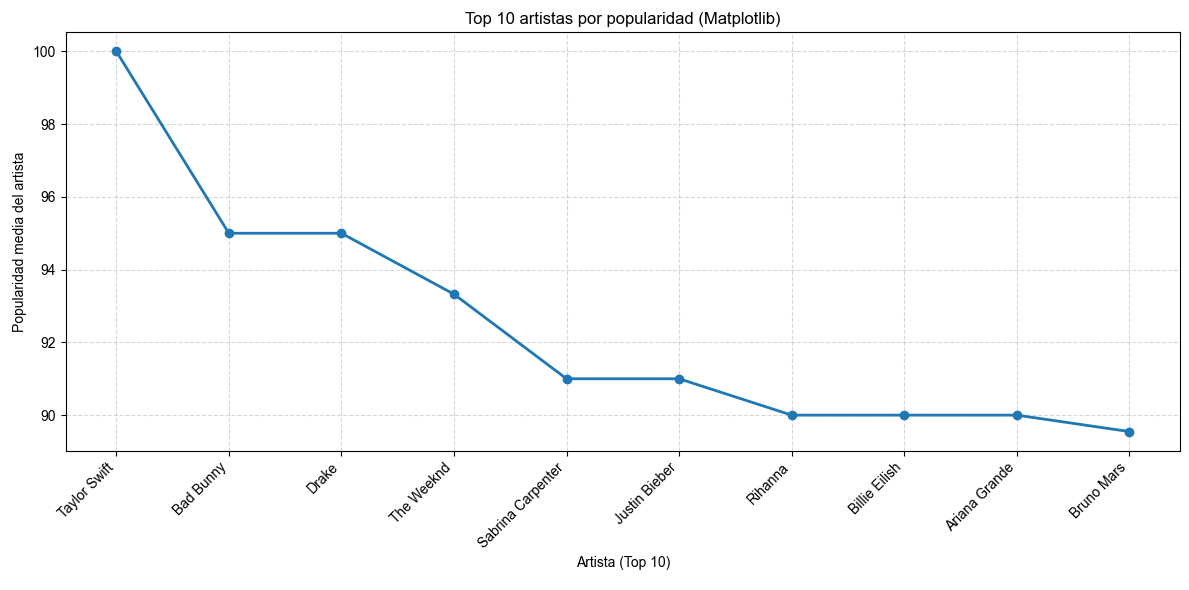

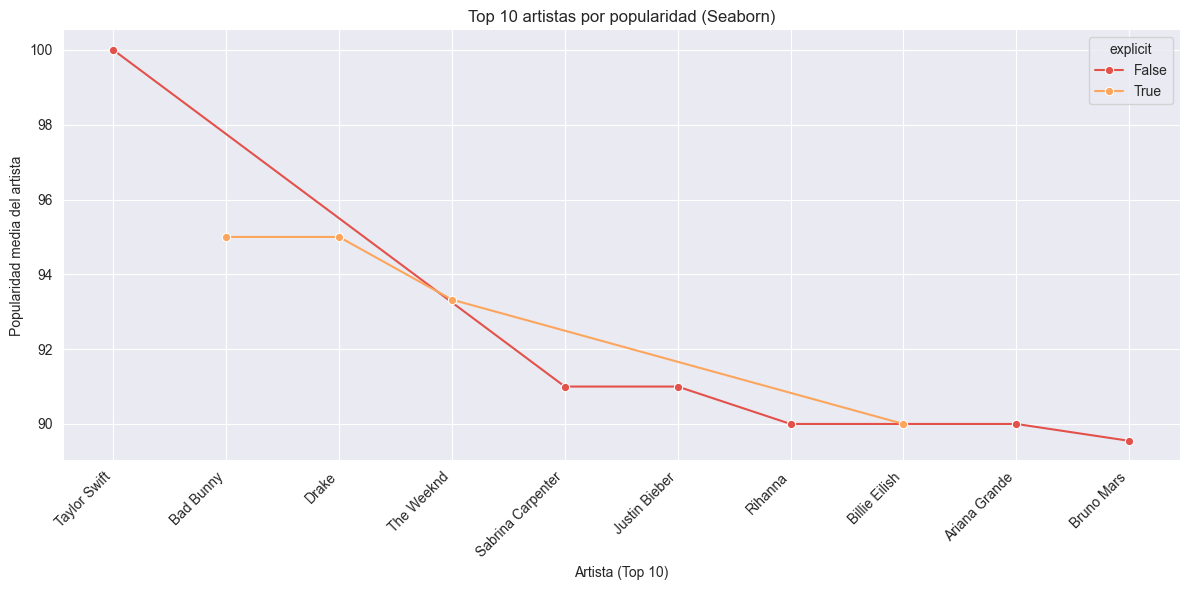

In [ ]:
# Obtenemos el top 10 de artistas más populares
top10 = (df.groupby('artist_name', as_index=False)['artist_popularity']
          .mean()
          .sort_values('artist_popularity', ascending=False)
          .head(10))


# Añadimos columna 'explicit' para se
# Tomamos el primer valor de explicit de cada artista ---> seaborn con hue ya lo leeria y enseñaria , matplotlib NO (Filtrar los datos por cada grupo)
explicit_col = df.groupby('artist_name')['explicit'].first().reset_index()
top10 = top10.merge(explicit_col, on='artist_name')


# Creamos una nueva columna "rank" y sumamos 1 porque si no el top sería del 0 al 9
top10 = top10.reset_index(drop=True)
top10['rank'] = top10.index + 1

# Matplotlib
print()
plt.figure(figsize=(12, 6))
plt.plot(top10['rank'], top10['artist_popularity'],
         marker='o', linestyle='-', color='tab:blue', linewidth=2)
plt.xticks(top10['rank'], top10['artist_name'], rotation=45, ha='right')
plt.xlabel("Artista (Top 10)")
plt.ylabel("Popularidad media del artista")
plt.title("Top 10 artistas por popularidad (Matplotlib)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Seaborn (con su propio tema)
# si queremos que los estilos se apliquen a un solo bloque 'with' , ya que de otra manera los estilos se configuran globalmente 
with sns.axes_style("darkgrid"):
    sns.set_palette("Spectral") ##--> Tambien lo podemos colocar en la line lineplot(palette=...)
# Seaborn
    plt.figure(figsize=(12,6))
    sns.lineplot(x='rank', y='artist_popularity', data=top10, marker='o', sort=False, hue='explicit') #con seaborn muy facil añadir nuevos datos con hue
    plt.xticks(top10['rank'], top10['artist_name'], rotation=45, ha='right')
    plt.xlabel("Artista (Top 10)")
    plt.ylabel("Popularidad media del artista")
    plt.title("Top 10 artistas por popularidad (Seaborn)")
    sns.despine()# Eliminamos bordes superiores y derechos del gráfico para hacerlo más limpio
    plt.tight_layout()
    plt.show()

#Conclusión práctica
#Matplotlib: necesitas un for para cada grupo  más control, más trabajo.
#Seaborn: basta con pasar la columna categórica a hue mucho más cómodo y limpio.


---
### Gráfico de barras

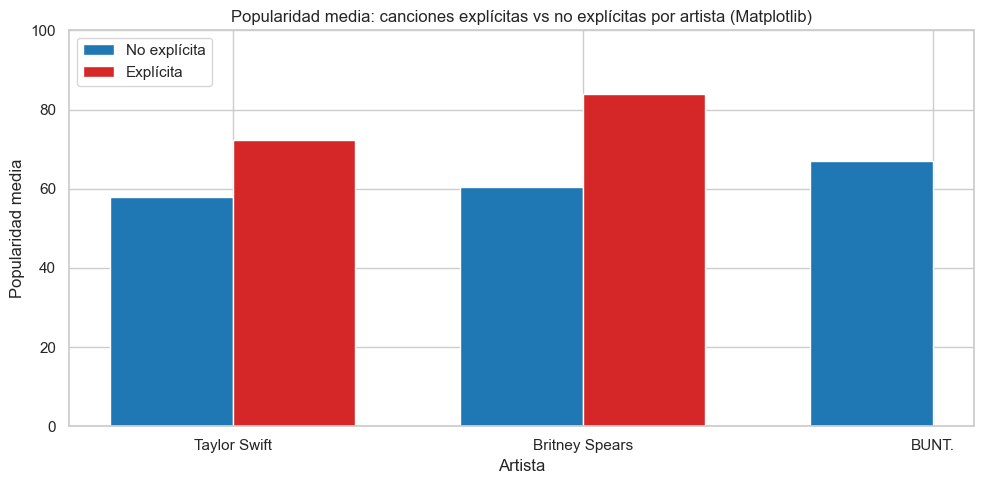

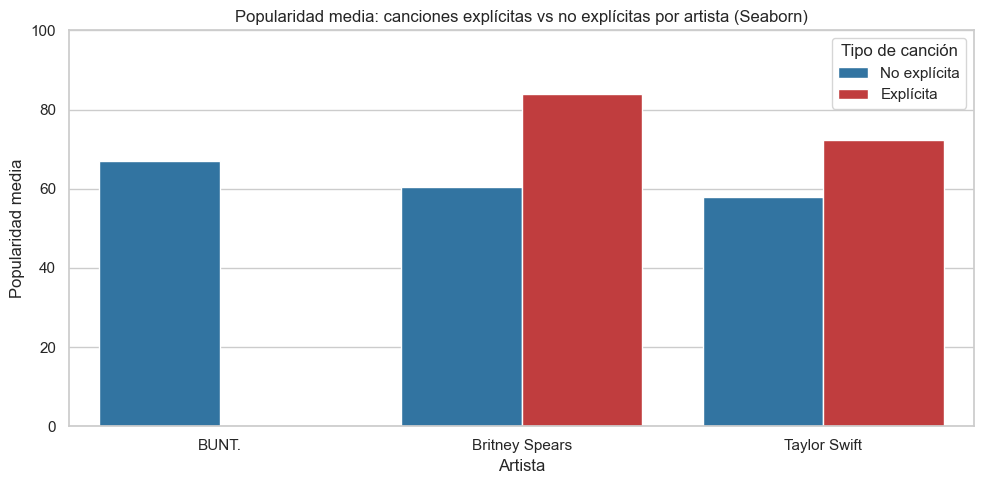

In [12]:
# Filtramos los artistas que queremos comparar
artists = ['Taylor Swift', 'Britney Spears', 'BUNT.']
df_subset = df[df['artist_name'].isin(artists)]
# Matplotlib
width = 0.35  # ancho de cada barra
x = range(len(artists))

# Calculamos los valores para explícitas y no explícitas
vals_no_exp = []
vals_exp = []
# En Matplotlib no existe un parámetro 'hue' automático.
# Para barras agrupadas, necesitamos calcular manualmente los valores
# de cada subcategoría (explícitas/ no explícitas) y ajustar las posiciones.
for artist in artists:
    df_artist = df[df['artist_name']==artist]
    vals_no_exp.append(df_artist[df_artist['explicit']==False]['track_popularity'].mean())
    vals_exp.append(df_artist[df_artist['explicit']==True]['track_popularity'].mean())

plt.figure(figsize=(10,5))
plt.bar([i - width/2 for i in x], vals_no_exp, width=width, color='tab:blue', label='No explícita')
plt.bar([i + width/2 for i in x], vals_exp, width=width, color='tab:red', label='Explícita')

plt.xticks(x, artists)
plt.ylim(0,100)
plt.xlabel("Artista")
plt.ylabel("Popularidad media")
plt.title("Popularidad media: canciones explícitas vs no explícitas por artista (Matplotlib)")
plt.legend()
plt.tight_layout()
plt.show()


# Seaborn

# Preparamos datos: promedio por artista y explicit
group = (df_subset.groupby(['artist_name','explicit'], as_index=False)['track_popularity']
         .mean()
         .rename(columns={'track_popularity':'avg_popularity'}))
group['label'] = group['explicit'].map({False:'No explícita', True:'Explícita'})

# Gráfico de barras
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,5))
##podemos cambiar facil el orden, incluso del hue -- dodge --> para que nos e solapen
sns.barplot(x='artist_name', y='avg_popularity', hue='label', data=group, palette=['tab:blue','tab:red'],hue_order=['No explícita','Explícita'])

plt.ylim(0,100)
plt.xlabel("Artista")
plt.ylabel("Popularidad media")
plt.title("Popularidad media: canciones explícitas vs no explícitas por artista (Seaborn)")
plt.legend(title="Tipo de canción")
plt.tight_layout()
plt.show()


---
### Histograma

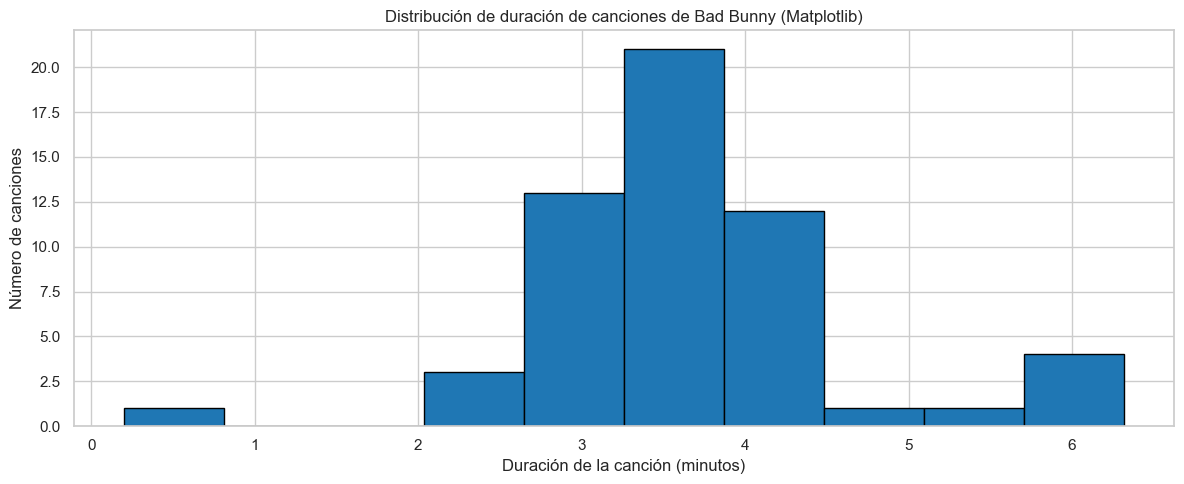

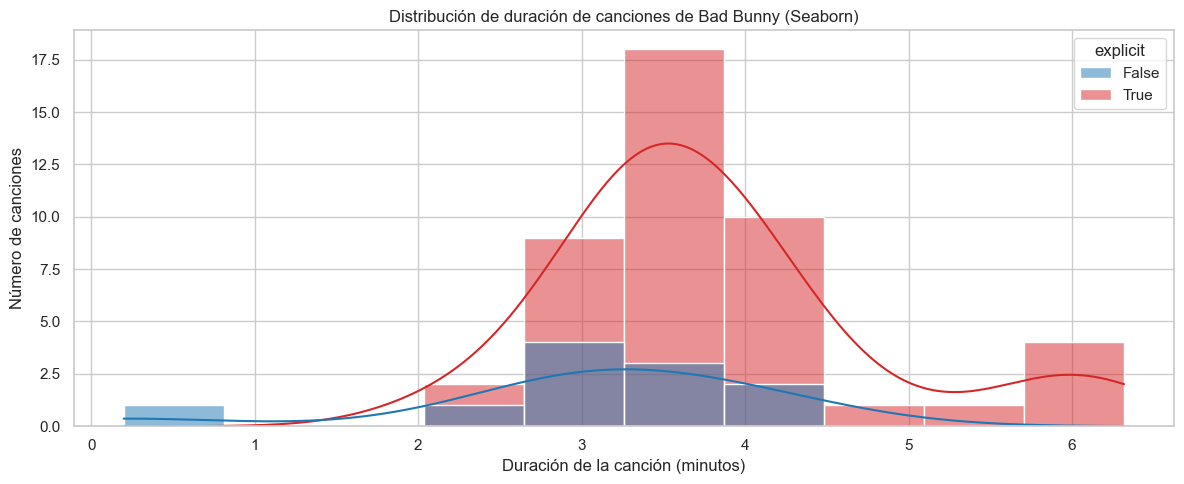

In [ ]:
# Convertimos la duración de milisegundos a minutos
df['track_duration_min'] = df['track_duration_ms'] / 60000  # 60,000 ms = 1 min
# Filtramos un artista de ejemplo
artist = "Bad Bunny"
df_artist = df[df['artist_name'].str.lower() == artist.lower()]
#Matplotlib
# en Mat tendriamos que separar los datos manualmente
# df_exp = df_artist[df_artist['explicit'] == True]['track_duration_min']
# df_no_exp = df_artist[df_artist['explicit'] == False]['track_duration_min']
plt.figure(figsize=(12,5))
plt.hist(df_artist['track_duration_min'], bins=10, color='tab:blue', edgecolor='black')
#plt.hist(df_exp, bins=10, alpha=0.6, color='tab:red', label='Explícita')
plt.xlabel("Duración de la canción (minutos)")
plt.ylabel("Número de canciones")
plt.title(f"Distribución de duración de canciones de {artist} (Matplotlib)")
plt.tight_layout()
plt.show()

# Seaborn
sns.set_theme(style="whitegrid")  # tema moderno y grid
plt.figure(figsize=(12,5))
#con simplemente hue añadimos otro dato
sns.histplot(df_artist, x='track_duration_min', bins=10, hue='explicit', palette=['tab:blue','tab:red'], kde=True)
plt.xlabel("Duración de la canción (minutos)")
plt.ylabel("Número de canciones")
plt.title(f"Distribución de duración de canciones de {artist} (Seaborn)")
plt.tight_layout()
plt.show()

---
### Gráfico de dispersión

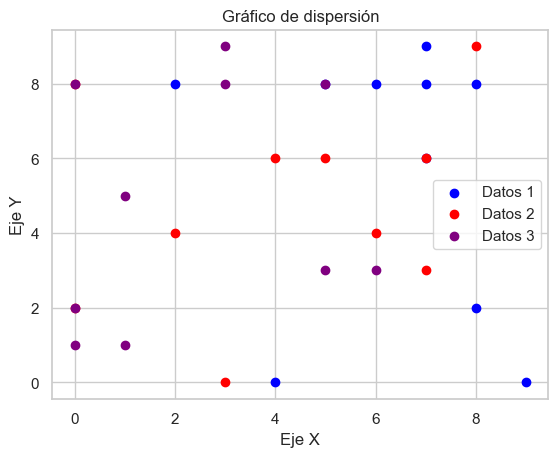

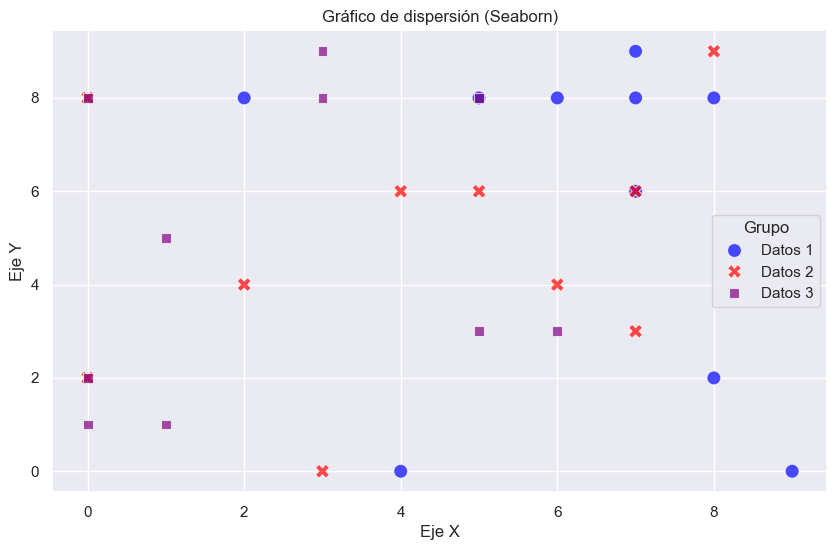

In [8]:

x1 = np.random.randint(10, size = [10])
x2 = np.random.randint(10, size = [10])
y1 = np.random.randint(10, size = [10])
y2 = np.random.randint(10, size = [10])
x3 = np.random.randint(10, size = [10])
y3 = np.random.randint(10, size = [10])

# Matplotlib
# configuramos los datos de cada matriz en el gráfico
plt.scatter(x1, y1, label = "Datos 1", color = "blue")
plt.scatter(x2, y2, label = "Datos 2", color = "red")
plt.scatter(x3, y3, label = "Datos 3", color = "purple")

# definimos el título y nombre de los ejes
plt.title("Gráfico de dispersión")
plt.xlabel("Eje X")
plt.ylabel("Eje Y")
plt.legend()

plt.show()
#Seaborn

dfd = pd.DataFrame({
    "x": np.concatenate([x1, x2, x3]),
    "y": np.concatenate([y1, y2, y3]),
    "grupo": ["Datos 1"]*10 + ["Datos 2"]*10 + ["Datos 3"]*10
})
with sns.axes_style("darkgrid"): 
    plt.figure(figsize=(10,6))
    # Usando DataFrame y hue para separar grupos automáticamente
    sns.scatterplot(
        data=dfd,     
        x="x",       
        y="y",        
        hue="grupo",  
        style="grupo",# cambia forma segun grupo
        palette=["blue","red","purple"],  
        s=100,       
        alpha=0.7 
    )

    plt.title("Gráfico de dispersión (Seaborn)")
    plt.xlabel("Eje X")
    plt.ylabel("Eje Y")
    plt.legend(title="Grupo")
    plt.show()

---
### Gráfico circular (Seaborn no tiene gráfico circular)

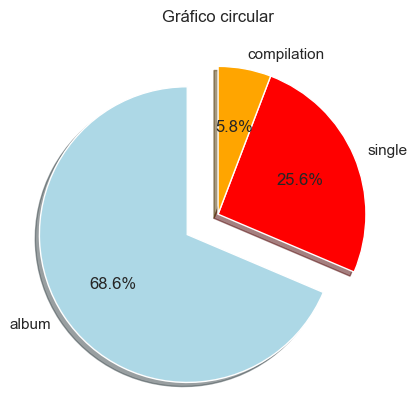

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12784\3395378667.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


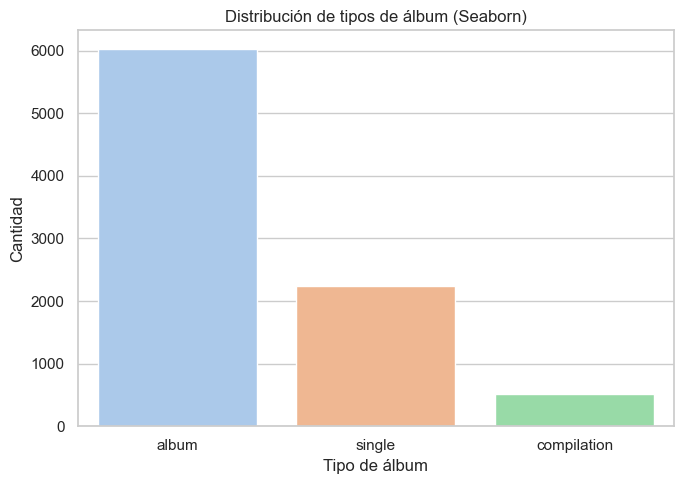

In [9]:
#Matplotlib
datos = df["album_type"].value_counts()
actividades = datos.index  # <-- aquí está el cambio importante
colores = ["lightblue", "red", "orange", "green", "yellow"]
plt.pie(
    datos,
    labels=actividades,
    colors=colores, 
    startangle=90,
    shadow=True,
    explode=(0.25,0,0), 
    autopct="%1.1f%%"
)
plt.title("Gráfico circular")
plt.show()


# ¿Por qué Seaborn no tiene pieplot?
# Porque su enfoque es estadístico y comparativo, no decorativo.
# Seaborn está diseñado para mostrar relaciones entre variables, 
# distribuciones y comparaciones cuantitativas (barras, boxplots, violinplots, scatterplots, heatmaps, etc.).
# Los gráficos de pastel (pie charts) no son muy precisos para comparar proporciones — son más visuales que analíticos.
# Por eso, los autores de Seaborn decidieron no incluir gráficos circulares.
# De hecho, el propio creador de Seaborn (Michael Waskom) ha explicado que los gráficos circulares 
# “no son recomendables para análisis cuantitativo”, y que para mostrar proporciones es mejor usar gráficos de barras o donut charts con Matplotlib.
album_counts = df["album_type"].value_counts().reset_index()
album_counts.columns = ["album_type", "count"]
sns.set_theme(style="whitegrid")

plt.figure(figsize=(7,5))
sns.barplot(
    data=album_counts,
    x="album_type",
    y="count",
    palette="pastel"
)
plt.title("Distribución de tipos de álbum (Seaborn)")
plt.xlabel("Tipo de álbum")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()

# Swarmplot

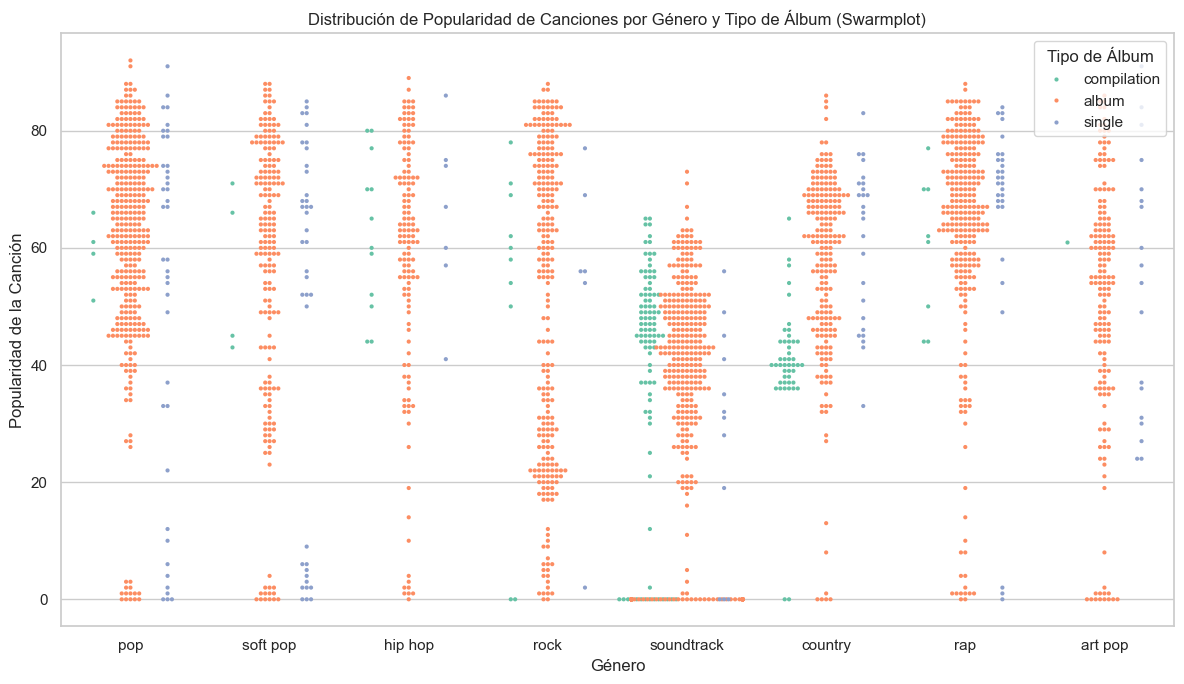

In [10]:
df_exploded = df.copy()

# Convierte a una lista
df_exploded['artist_genres_list'] = df_exploded['artist_genres'].str.strip("[]").str.replace("'", "").str.split(", ")

# Esplote() para que cada género sea una fila
df_exploded = df_exploded.explode('artist_genres_list')

# Elimina vacíos
df_exploded = df_exploded[
    (df_exploded['artist_genres_list'].str.strip() != "") 
]

# display(df[['artist_name', 'artist_genres']].head(10))

# Renombra la columna para claridad y elimina la columna original
df_exploded = df_exploded.rename(columns={'artist_genres_list': 'artist_genre'}).drop(columns=['artist_genres'])

# display(df_exploded[['artist_name', 'artist_genre']].head(10))

# Filtra los géneros más frecuentes
top_genres = df_exploded['artist_genre'].value_counts().head(8).index.tolist()
df_swarm = df_exploded[df_exploded['artist_genre'].isin(top_genres)]

plt.figure(figsize=(12, 7))
sns.swarmplot(
    # Datos y variables
    data=df_swarm,                       
    x='artist_genre',                     
    y='track_popularity',                  
    hue='album_type',                      
    
    # Control de orden
    order=None,                             
    hue_order=None,                         
    
    # Orientación
    orient='v',                           
    
    # Colores y apariencia
    color=None,                             
    palette='Set2',                         
    
    # Tamaño y forma de puntos
    size=3,                                
    marker='o',                            
    alpha=None,                            
    edgecolor='auto',                      
    linewidth=0,                            
    
    # Separación y distribución
    dodge=True,                            
    warn_thresh=0.5,                       
)

plt.title('Distribución de Popularidad de Canciones por Género y Tipo de Álbum (Swarmplot)')
plt.xlabel('Género')
plt.ylabel('Popularidad de la Canción')
plt.legend(title='Tipo de Álbum')
plt.tight_layout()
plt.show()

# Heatmap

<Axes: xlabel='year', ylabel='month'>

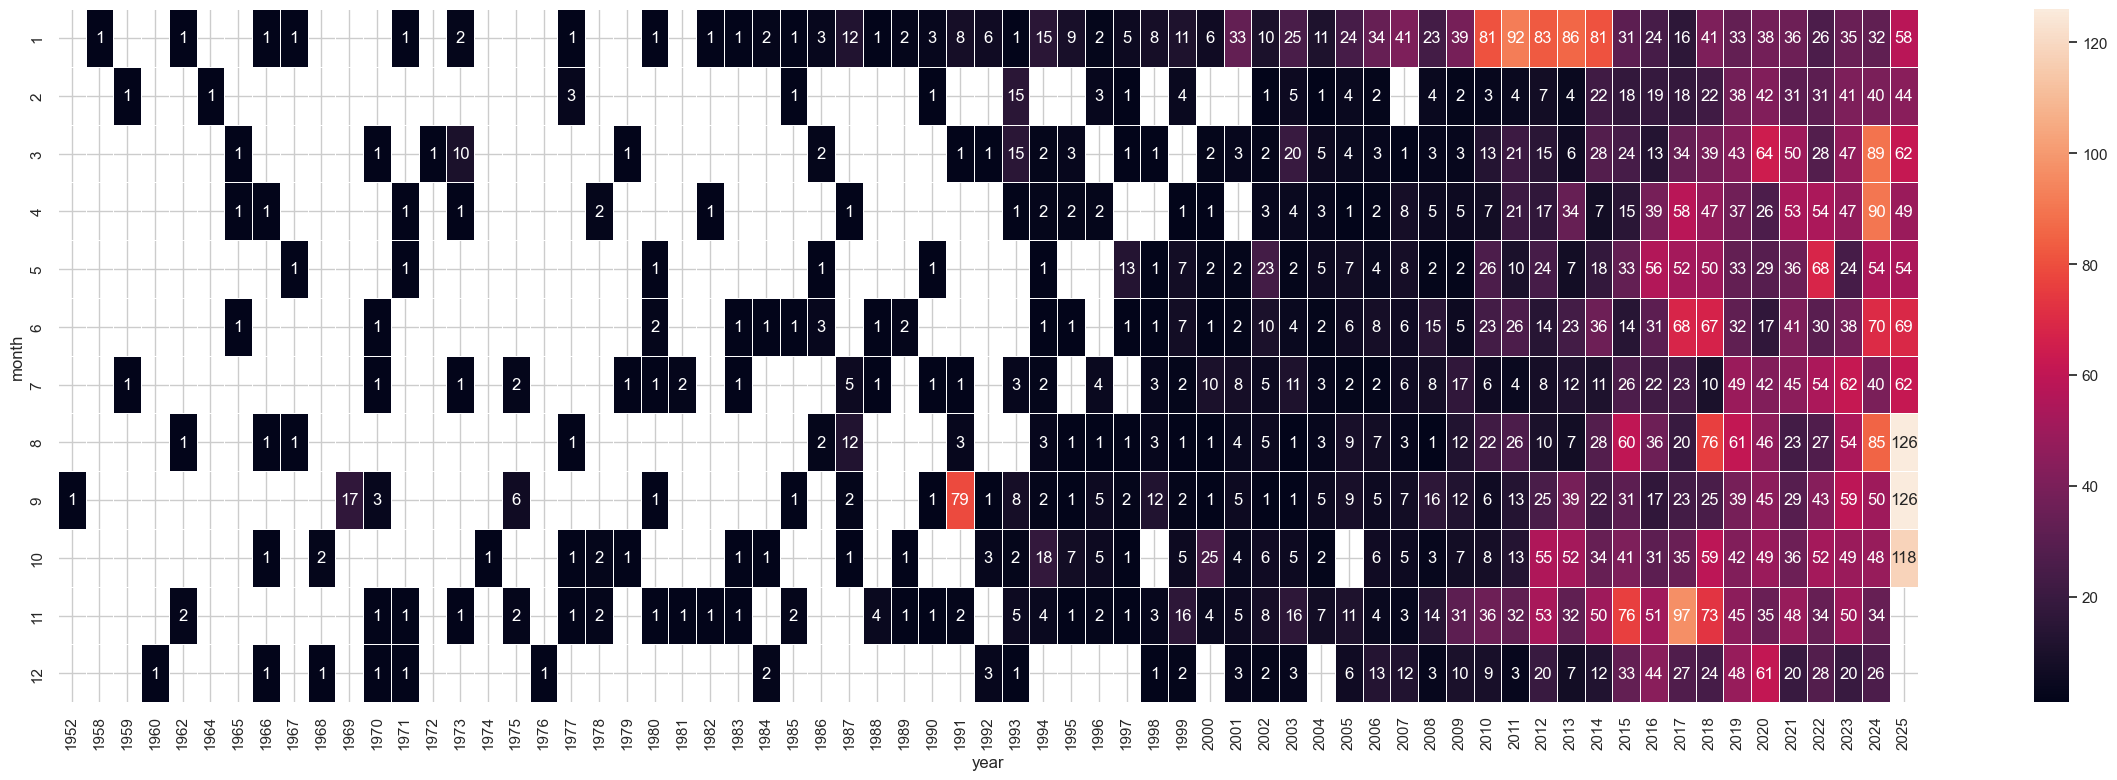

In [23]:
# En el dataframe original, algunas fechas no están completas (solo año o año-mes) (por ejemplo, "2005" o "2005-07")
# Eliminar filas donde album_release_date tiene exactamente 7 caracteres o menos
mask_short = df['album_release_date'].astype(str).str.len() <= 7
# Mantener solo las filas que NO cumplen la condición
df = df[~mask_short].reset_index(drop=True)

df["album_release_date"] = pd.to_datetime(df["album_release_date"])
df_heatmap = df.copy()
df_heatmap["year"] = df['album_release_date'].dt.year
df_heatmap["month"] = df['album_release_date'].dt.month
df_heatmap = (
    df_heatmap
    .pivot_table(index="month", columns="year", values="album_name", aggfunc="count")
)

f, ax = plt.subplots(figsize=(30, 9))
sns.heatmap(df_heatmap, annot=True, fmt=".0f", linewidths=.5, ax=ax)